# Dimensionality reduction with PCA and Clustering with K-means, Hierarchical Clustering, and DBSCAN

In [1]:
import pandas as pd # Pandas
import numpy as np # Numpy
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
# Load the data
####################################################
data = pd.read_csv(
    r"C:\Users\isabe\Downloads\TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    r'C:\Users\isabe\OneDrive\Documents\BME2315\Grosso-Orlando-Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
#print(data.head())

# %%
# Explore the data
####################################################
#print(data.shape)
#print(data.info())
#print(data.describe())

# %%
# Explore the metadata
####################################################
#print(metadata_df.info())
#print(metadata_df.describe())

# %%
# Subset the data for a specific cancer type
####################################################
cancer_type = 'BRCA'  # Breast Invasive Carcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
#print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
BRCA_data = data[cancer_samples]

# %%
# Subset by index (genes)
####################################################
with open(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\code\Menyhart_JPA_CancerHallmarks_core.txt","r") as f:
    lines = f.readlines()


sp_line = lines[8].split("\t") #line 9 - index 8
desired_gene_list = [gene.strip() for gene in sp_line if gene.strip() not in ["SUSTAINING PROLIFERATIVE SIGNALING",""]]
desired_gene_list = list(set(desired_gene_list))
gene_list = [gene for gene in desired_gene_list if gene in BRCA_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")
#print(desired_gene_list)
# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
BRCA_gene_data = BRCA_data.loc[gene_list]
#print(BRCA_gene_data.head())

# %%
# Basic statistics on the subsetted data
####################################################
#print(BRCA_gene_data.describe())
#print(BRCA_gene_data.var(axis=1))  # Variance of each gene across samples
# Mean expression of each gene across samples
#print(BRCA_gene_data.mean(axis=1))
# Median expression of each gene across samples
#print(BRCA_gene_data.median(axis=1))

# %%
# Merging datasets
####################################################
# Merge the subsetted expression data with metadata for BRCA samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
BRCA_metadata = metadata_df.loc[cancer_samples]
BRCA_merged = BRCA_gene_data.T.merge(
    BRCA_metadata, left_index=True, right_index=True)


In [3]:
#Show DataFrame
data = BRCA_merged[gene_list]
data

,SFRP1,TGFB1,IL11,GNA12,GLI1,MAP3K13,DGKE,ITGAV,CREB3L2,AR,...,IRS1,EPOR,PRKCB,ADORA1,GNG13,FGFR1,GNB2,TRADD,FES,LCK
TCGA-E9-A1NI-01A-11R-A14D-07,2.168144,5.810154,0.942891,5.133681,1.027200,3.291732,1.660188,5.436458,5.097844,5.643128,...,3.941903,2.960146,0.480698,3.770333,2.918405,4.829254,8.492602,4.714961,2.907674,1.465063
TCGA-E2-A1LK-01A-21R-A14D-07,10.412343,5.208492,0.591141,5.810230,0.506943,2.652283,2.982974,6.136192,5.933272,0.150557,...,2.487864,1.899921,0.230882,3.644271,0.489385,4.795113,8.433154,4.820739,3.946880,2.461612
TCGA-BH-A0B2-01A-11R-A10J-07,6.102498,6.863236,0.582914,5.245094,1.725970,3.122273,1.611484,5.592393,5.376821,6.065112,...,4.357369,2.683894,2.809033,2.640686,0.532709,5.709929,7.990173,5.089564,3.958744,4.699003
TCGA-E2-A107-01A-11R-A10J-07,4.384891,5.001450,0.537788,5.406030,0.709176,3.363101,1.703121,4.430490,5.066735,5.566165,...,4.109997,2.339813,0.836366,3.220445,0.758429,5.675103,9.651970,4.658392,2.789110,2.310975
TCGA-LL-A5YN-01A-11R-A28M-07,3.002508,6.555903,0.768661,4.626229,1.060563,2.549050,1.683314,4.031735,3.745735,4.732802,...,2.688108,3.594566,3.069341,2.793739,1.975980,4.027062,8.563557,6.030810,3.997984,6.171252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-E9-A5UP-01A-11R-A28M-07,0.050139,5.475429,0.393057,5.178130,0.041396,3.307444,3.403059,4.071604,5.267836,4.710519,...,1.356803,4.201326,0.519711,5.008568,1.191776,6.276460,8.255287,5.518563,2.277111,1.154613
TCGA-AR-A24T-01A-11R-A169-07,5.745308,6.798330,0.670946,6.156147,1.993709,3.763077,1.817071,7.669351,5.696297,7.227676,...,5.594699,3.124219,1.871600,3.506718,0.126163,5.757230,8.104941,4.042029,3.811813,2.375232
TCGA-D8-A1XB-01A-11R-A14D-07,4.999752,6.175135,1.414505,6.250374,1.252609,3.201473,2.317856,6.714612,5.977474,6.919087,...,5.243139,3.629979,1.293336,2.858612,1.204990,6.234101,8.126074,5.061247,3.433717,1.885364
TCGA-E9-A245-01A-22R-A16F-07,4.572815,6.128735,0.985557,5.283571,0.961550,2.508158,2.998602,5.041328,4.661082,4.702646,...,4.754171,2.131053,0.715077,4.541550,0.342505,5.700551,8.995240,4.535730,3.731843,1.124847


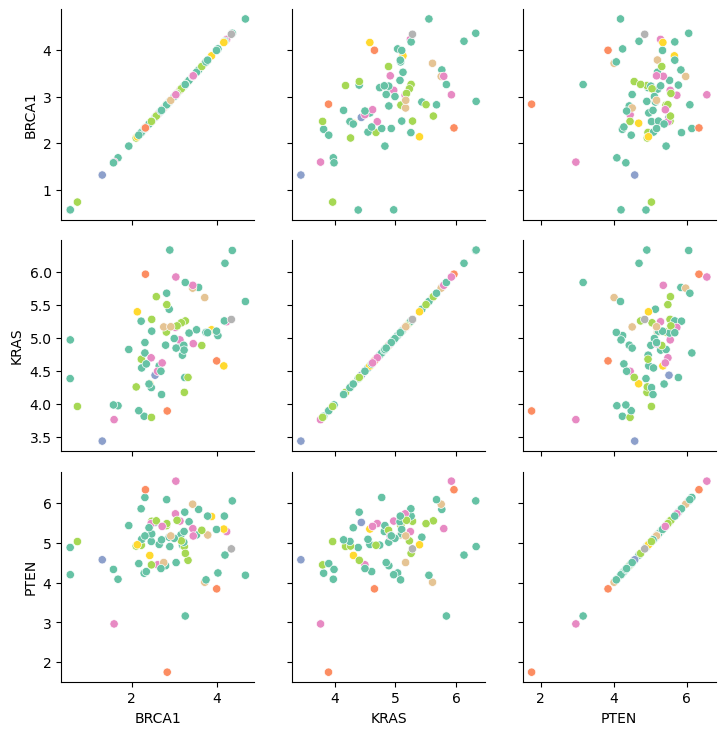

In [7]:
df = BRCA_merged[['BRCA1','KRAS','PTEN']].copy()
df["cluster"] = BRCA_merged['ajcc_tumor_pathologic_pt'].astype(str)
g = sns.PairGrid(df, hue = "cluster", palette = "Set2")
g.map(sns.scatterplot)
g.add_legend
plt.show()

In [21]:
clean = BRCA_merged[BRCA_merged['tumor_status'].isin(['TUMOR FREE', 'WITH TUMOR'])]
top50 = clean[gene_list].var().nlargest(50).index.tolist()

X = clean[top50]
Y = clean['tumor_status'].astype(str)


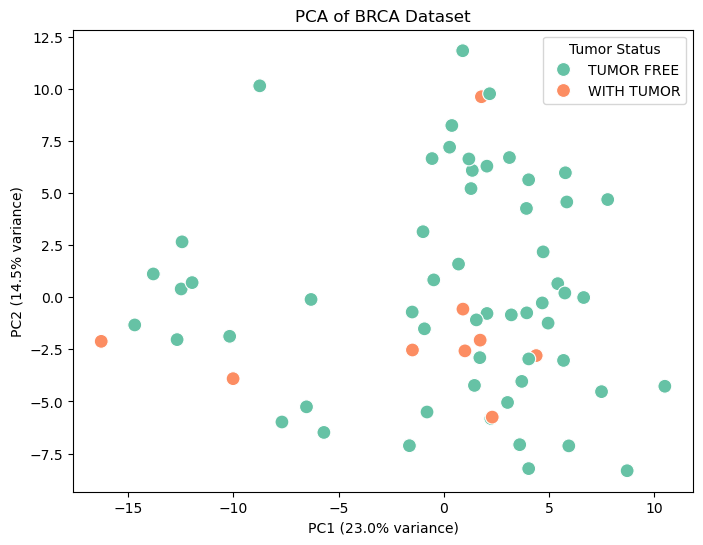

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=Y,
    palette="Set2",
    s=100
)
plt.title("PCA of BRCA Dataset")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Tumor Status")
plt.show()

Tumor status indicates whether or not cancer cells are actively growing. Using genes from the sustained proliferative signals hallmark, 50 with the highest variability were selected for the PCA in order to decrease noise from genes that did not vary depending on the sample. Each point in the PCA was colored depending on tumor status of the sample. Active tumor samples are clustering in the lower right quadrant, with PC1 positive and PC2 negative. This suggests that there may be a combination of sustained growth gene expression that is positively correlated with active cancer growth. Although there appears to be a trend in the data, there are significantly less samples with an active tumor so there is not a definitive conclusion from this data.

## K-Means

c:\Users\isabe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


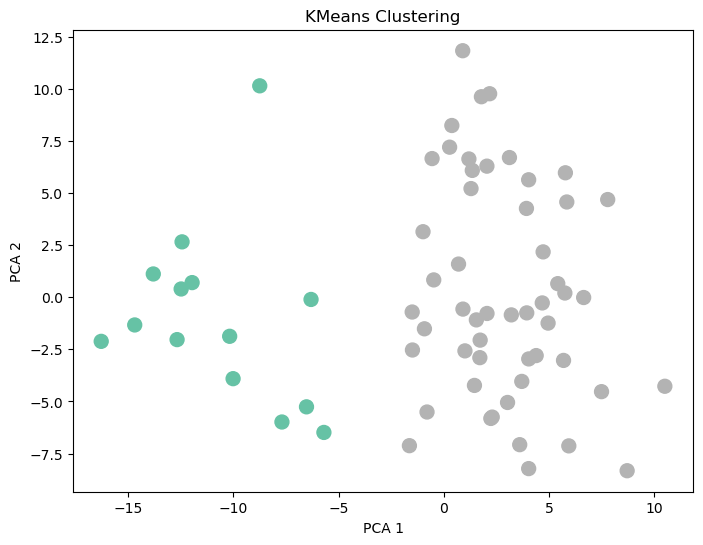

In [24]:
model = KMeans(n_clusters=2, random_state=0)
model.fit(X)
y_pred = model.predict(X)
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap="Set2", s=100)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clustering")

plt.show()

Now, try to compare the labels that were found using k-means to the true labels (y) to see how well the model did. Keep in mind that we usually will not have the true labels.

In [29]:
y_pred

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1],
      dtype=int32)

In [27]:
Y

TCGA-E9-A1NI-01A-11R-A14D-07    TUMOR FREE
TCGA-E2-A1LK-01A-21R-A14D-07    WITH TUMOR
TCGA-BH-A0B2-01A-11R-A10J-07    TUMOR FREE
TCGA-E2-A107-01A-11R-A10J-07    WITH TUMOR
TCGA-BH-A0DQ-01A-11R-A084-07    TUMOR FREE
                                   ...    
TCGA-AO-A1KQ-01A-11R-A13Q-07    TUMOR FREE
TCGA-E9-A5UP-01A-11R-A28M-07    TUMOR FREE
TCGA-D8-A1XB-01A-11R-A14D-07    TUMOR FREE
TCGA-E9-A245-01A-22R-A16F-07    TUMOR FREE
TCGA-WT-AB44-01A-11R-A41B-07    TUMOR FREE
Name: tumor_status, Length: 66, dtype: object

In [32]:
# We can see above the labels 0 and 1 are mismatched, so if we compared them directly our accuracy would be low. Let's swap labels 0 and 1
y_pred_swapped = y_pred.copy()
y_pred_swapped[y_pred == 1] = 0
y_pred_swapped[y_pred == 0] = 1

print(y_pred_swapped)

[0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0
 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0]


In [33]:
Y_assigned = (Y == 'WITH TUMOR').astype(int) # TUMOR FREE = 0, WITH TUMOR = 1

correct = 0
incorrect = 0
for i, x in enumerate(y_pred_swapped):
    if Y_assigned.iloc[i] == x:
        correct += 1
    else:
        incorrect += 1
print("Correct: ", correct)
print("Incorrect: ", incorrect)
# Calculate the accuracy
accuracy = correct / (correct + incorrect)
print("Accuracy: ", accuracy)

Correct:  47
Incorrect:  19
Accuracy:  0.7121212121212122


KMeans is an unsupervised machine learning model, which sorted the data into 2 clusters based on similarity. It was done on unlabeled data, and after the results were compared to the sample label (TUMOR or TUMOR FREE) and was found to have sorted the data into 2 clusters with approximately 71% accuracy. This shows that the data was clustered beyond just randomness, which would have been around 50%. Because this unsupervised model was able to cluster the data points by similarity beyond just randomess, there is further support for a correlation between sustained proliferation signaling and tumor status.

## Hierachical Clustering

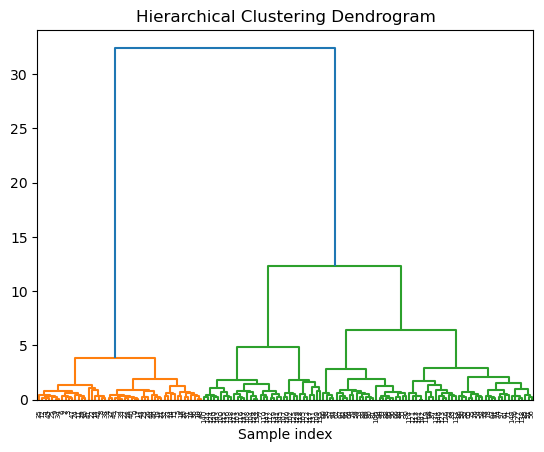

In [ ]:

# hierachical clustering on Iris data using sklearn AgglomerativeClustering

import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


iris = load_iris()
X = iris.data

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model)
plt.xlabel("Sample index")
plt.show()


## DBSCAN

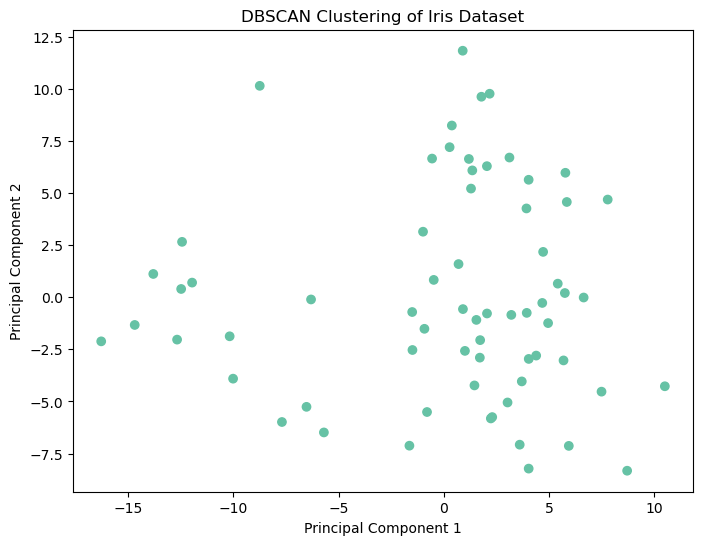

In [34]:
# use DBSCAN to cluster the iris data
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan, cmap="Set2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering of Iris Dataset")
plt.show()

## UMAP

If you want to do a UMAP, you need to `pip install umap` to get the right package: https://umap-learn.readthedocs.io/en/latest/basic_usage.html. The syntax for this package is very similar to sklearn!

In [36]:
!pip install umap-learn 
#this way of installing packages is for Jupyter notebooks, if you are running this code in a .py file you should install the package in your terminal using pip install umap-learn


   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



In [39]:
from sklearn.preprocessing import StandardScaler
import umap

scaled_data = StandardScaler().fit_transform(X)

reducer = umap.UMAP()
X_umap = reducer.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette="Set2", s=100)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of BRCA Dataset")
plt.show()

NameError: name 'y' is not defined

<Figure size 800x600 with 0 Axes>